<a href="https://colab.research.google.com/github/ds-20195/notebooks/blob/main/drafts/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data and the State
**DATA 21905/31905**

# Week 1: 3/24 - 3/27

# Lab 1: Introduction to Python and Census

## Resources



* Python
  * [DataCamp's interactive Intro to Python tutorial](https://www.learnpython.org/)
  * [Python for Everybody (University of Michigan MOOC)](https://www.py4e.com/lessons)
  * [A short Python and NumPy tutorial (Stanford CS231)](http://cs231n.github.io/python-numpy-tutorial/)
  * [Official Python tutorial](https://docs.python.org/3/tutorial/index.html)
  * [Jake VanderPlas' _A Whirlwind Tour of Python_](https://github.com/jakevdp/WhirlwindTourOfPython/tree/master?tab=readme-ov-file) (particularly chapters 1–8)
  * [Cornell CS 1110 lecture videos (Fall 2020)](https://vod.video.cornell.edu/channel/CS+1110+Fall+2020/179890731)
* Pandas
    * [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html)
    * [Official pandas tutorials](https://pandas.pydata.org/docs/getting_started/index.html#intro-to-pandas)
    * [Data Manipulation with Pandas (chapter 3 of VanderPlas' *Python Data Science Handbook*)](https://jakevdp.github.io/PythonDataScienceHandbook/03.00-introduction-to-pandas.html)
    * [Introduction to GeoPandas](https://github.com/geopandas/geopandas/blob/main/doc/source/getting_started/introduction.ipynb) (Jupyter notebook)
    * [Comparison with R / R libraries](https://pandas.pydata.org/docs/getting_started/comparison/comparison_with_r.html) (a handy Rosetta stone if you've previously used R!)
    * [UC Berkeley Data 100 Early Lectures on Pandas and Visualization](https://ds100.org/su25/)
* Matplotlib
  * [Official Pyplot tutorial (short)](https://matplotlib.org/tutorials/introductory/pyplot.html)
  * [Visualization with Matplotlib (chapter 4 of VanderPlas' *Python Data Science Handbook*)](https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html)
  * [Gallery of Matplotlib examples](https://matplotlib.org/gallery/index.html)

   

## Exploring the US Census

In lab section, we'll explore the most famous and essential dataset published by the U.S. Census Bureau: the decennial enumeration of the U.S. population. This enumeration is [required by Article I of the U.S. Constitution](https://www.census.gov/programs-surveys/decennial-census/about/census-constitution.html), and the challenges of processing Census data as the national population grew throughout the 19th century led to the development of [a tabulating machine](https://www.computerhistory.org/revolution/punched-cards/2/2) that was [first used for processing the 1890 U.S. Census](https://www.smithsonianmag.com/smithsonian-institution/herman-holleriths-tabulating-machine-2504989/). This machine read punched cards that encoded Census responses and generated summary statistics (such as the number of foreign-born children under 18 in a particular state, or the number of married women in a particular city). The company that developed this tabulating machine was later renamed to IBM.

The technical demands of analyzing U.S. Census data were therefore a catalyst in the early development of computing; in the 130 years or so since the dawn of this automated tabulation technology, Census data has become exponentially more detailed and accessible. Here, we'll focus on a small slice of the 2010 and 2020 decennial Census data published online via the [Census API](https://www.census.gov/data/developers/data-sets.html).

First we need to do some package setups. Run the follwing cells.

It is not important that you understand the technical details of package set up, but feel free to read the comments below to get a basic idea.

In [1]:
# You can ignore the contents of this cell for now. This is just to make sure we have the correct
# packages are installed for this lab.

# The `census` package is a wrapper around the US Census API, which allows us to easily query census
# data from Python easily. The `us` package provides a simple interface to get information about 
# US states, such as their names and abbreviations.
!pip install -q census us

zsh:1: /home/peter/.local/bin/pip: bad interpreter: /usr/bin/pypy: no such file or directory
error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try 'pacman -S
    python-xyz', where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Arch-packaged Python package,
    create a virtual environment using 'python -m venv path/to/venv'.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip.
    
    If you wish to install a non-Arch packaged Python application,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. Make sure you have python-pipx
    installed via pacman.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed spe

In [2]:
# Here we set up our working environment by importing the necessary packages, classes, and 
# functions.

# We import the `pandas` package, which is a powerful data manipulation library in Python. 
# It provides data structures like DataFrames that make it easy to work with structured data 
# (more on this later).
import pandas as pd


# From the `census` package, we import the `Census` class, which allows us to interact with the US 
# Census API an ergonomic way. We will use this class to query census data in this lab.
from census import Census

# From the `us` package, we import the `states` module, which provides information about US states,
# such as their names, abbreviations, and FIPS codes. This will be useful for working with census 
# data, which often uses FIPS (Federal Information Processing Standards) codes to identify states.
from us import states

## Fetching population data

Here, we'll retrieve population statistics by race from the Census API for all counties in Illinois. Census data releases are organized into tables; [Table P1](https://data.census.gov/table/DECENNIALPL2020.P1?g=040XX00US36) breaks down population by racial category. 

The official column names used by the Census Bureau are frequently inscrutable (for instance, the `P1_004N` column corresponds to Black population), and so we provide a dictionary below that we will later use to make working with the data more intuitive. (Full column definitions are available in the [API documentation](https://api.census.gov/data/2020/dec/pl/variables.html).)

In [3]:
p1_population_columns = {
    "P1_003N": "white",  # White alone
    "P1_004N": "black",  # Black or African American alone
    "P1_005N": "amin",  # American Indian and Alaska Native alone
    "P1_006N": "asian",  # Asian alone
    "P1_007N": "nhpi",  # Native Hawaiian and Other Pacific Islander alone
    "P1_008N": "other",  # Some Other Race alone
    "P1_009N": "two_or_more",  # Two or more races
}

When fetching data from the Census API, we usually identify geographic regions (states, counties, etc.) by their [FIPS code](https://en.wikipedia.org/wiki/Federal_Information_Processing_Standard_state_code). For instance, the FIPS code for the state of Illinois is 17. The `us` package exposes identifiers (FIPS codes, postal abbreviations) for the U.S. states.

In [4]:
state = states.IL
print(state, state.abbr, state.fips)

Illinois IL 17


Now we will make use of the `Census` class we imported from the `census` module and specify:
* The dataset we wish to query (in this case the `pl` dataset which stands for "Public Law 94-171")
* The columns we want to fetch from the chosen dataset (the `NAME` column, and the 7 columns from Table P1 listed in `p1_population_columns` above).
* The regions we want to fetch column values for (all counties in Illinois).

>Coding notes:
> * The syntax `f"state:{state.fips}"` is a kind of [string formatting](https://docs.python.org/3/tutorial/inputoutput.html) in Python, which allows you to dynamically change the content of the string based on other defined variables (in this case, `state.fips`). You can alternatively replace this code with the hard-coded FIPS values (e.g., `"state:01"`).
> * The asterisk `*` allows you to select *all* values corresponding to either counties or states.

In [10]:
census = Census(
    key="",      # We do not have a Census API key, so we leave this blank.
    year=2020    # We specify that we would like to use the 2020 Census data.
)

census_column_list = ["NAME"] + list(p1_population_columns.keys()) 
# The `NAME` column contains the name of the geographic area (in this case, the county name),
# and the keys of our `p1_population_columns` dictionary correspond were the columns P1_003N to 
# P1_009N in the census data, which contain the population counts for different racial groups.

county_populations = census.pl.get(
    census_column_list,
    geo={
        "for": "county:*",
        "in": f"state:{state.fips}",
    },
)

**Note: there are several ways to modify the above code to get data for *multiple* counties and *multiple* states.**

For example, if you want to get data for multiple counties you can simply list them out by their FIPS codes.

```
county_populations = census.pl.get(
    census_column_list,
    geo={
        "for": "county:001,002,003",
        "in": f"state:{state.fips}",
    }
)
```

Or, if you want to get data for all counties in *multiple states* you can list out the states by their FIPS codes.

```
county_populations = census.pl.get(
    census_column_list,
    geo={
        "for": "county:*",
        "in": "state:01,02",
    }
)
```

The Census API returns a list of dictionaries; each contains column values for a county which we can print out.

In [12]:
county_populations

[{'NAME': 'Adams County, Illinois',
  'P1_003N': 58837.0,
  'P1_004N': 2501.0,
  'P1_005N': 104.0,
  'P1_006N': 513.0,
  'P1_007N': 39.0,
  'P1_008N': 526.0,
  'P1_009N': 3217.0,
  'state': '17',
  'county': '001'},
 {'NAME': 'Alexander County, Illinois',
  'P1_003N': 3311.0,
  'P1_004N': 1617.0,
  'P1_005N': 24.0,
  'P1_006N': 6.0,
  'P1_007N': 0.0,
  'P1_008N': 20.0,
  'P1_009N': 262.0,
  'state': '17',
  'county': '003'},
 {'NAME': 'Bond County, Illinois',
  'P1_003N': 14446.0,
  'P1_004N': 1077.0,
  'P1_005N': 52.0,
  'P1_006N': 105.0,
  'P1_007N': 11.0,
  'P1_008N': 360.0,
  'P1_009N': 674.0,
  'state': '17',
  'county': '005'},
 {'NAME': 'Boone County, Illinois',
  'P1_003N': 38766.0,
  'P1_004N': 1245.0,
  'P1_005N': 498.0,
  'P1_006N': 659.0,
  'P1_007N': 24.0,
  'P1_008N': 6176.0,
  'P1_009N': 6080.0,
  'state': '17',
  'county': '007'},
 {'NAME': 'Brown County, Illinois',
  'P1_003N': 4779.0,
  'P1_004N': 1054.0,
  'P1_005N': 11.0,
  'P1_006N': 12.0,
  'P1_007N': 0.0,
  'P1_0

However, a list of dictionaries is not an ideal way of interacting with large datasets (unless you reall, really like for loops), so we will now make use of the data manipulation library `pandas`.

We can convert this raw response to a Pandas `DataFrame` without any further manipulation. For now, you can simply think of Pandas DataFrames as Python's version of spreadsheets. 

In [13]:
# We create the dataframe `race_df` from the list of dictionaries `county_populations`. 
# Each dictionary in the list represents a row in the dataframe, where the keys of the dictionary 
# correspond to the column names and the values correspond to the data in those columns.
#
# We also make sure to store the dataframe in a variable called `race_df`, which so we can extract
# data from it later on in the lab.
race_df = pd.DataFrame(county_populations)

# We will have colab print out the dataframe `race_df` so we can see what it looks like.
race_df

,NAME,P1_003N,P1_004N,P1_005N,P1_006N,P1_007N,P1_008N,P1_009N,state,county
0,"Adams County, Illinois",58837.0,2501.0,104.0,513.0,39.0,526.0,3217.0,17,001
1,"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,17,003
2,"Bond County, Illinois",14446.0,1077.0,52.0,105.0,11.0,360.0,674.0,17,005
3,"Boone County, Illinois",38766.0,1245.0,498.0,659.0,24.0,6176.0,6080.0,17,007
4,"Brown County, Illinois",4779.0,1054.0,11.0,12.0,0.0,210.0,178.0,17,009
...,...,...,...,...,...,...,...,...,...,...
97,"Whiteside County, Illinois",47759.0,839.0,235.0,311.0,12.0,2134.0,4401.0,17,195
98,"Will County, Illinois",443562.0,80979.0,3974.0,42849.0,126.0,54431.0,70434.0,17,197
99,"Williamson County, Illinois",58897.0,2870.0,263.0,776.0,9.0,554.0,3784.0,17,199
100,"Winnebago County, Illinois",191124.0,39159.0,1632.0,8039.0,84.0,19059.0,26253.0,17,201


Okay, that's a lot of data! Generally, we don't want to view our entire Dataframe, so we can instead use the `head(<number_of_rows.>)` and `tail(<number_of_rows>)` methods to take a peak at the first or last few rows of the DataFrame. 

In [14]:
race_df.head(3)

,NAME,P1_003N,P1_004N,P1_005N,P1_006N,P1_007N,P1_008N,P1_009N,state,county
0,"Adams County, Illinois",58837.0,2501.0,104.0,513.0,39.0,526.0,3217.0,17,001
1,"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,17,003
2,"Bond County, Illinois",14446.0,1077.0,52.0,105.0,11.0,360.0,674.0,17,005


## Data Querying and Postprocessing

Currently, our `race_df` dataframe is a bit hard to work with (what does "P1_005N" mean again?), but we can make `race_df` more usable by applying our mapping from raw column names to human-readable racial categories. Fortunately, pandas DataFrames provide us with a convenient way of doing this: the `rename` method.

Below is an example of how to use the `rename` method to change the column titled "state" to "state_fips_code".

In [15]:
race_df = race_df.rename(columns= {"state": "state_fips_code"})
race_df

,NAME,P1_003N,P1_004N,P1_005N,P1_006N,P1_007N,P1_008N,P1_009N,state_fips_code,county
0,"Adams County, Illinois",58837.0,2501.0,104.0,513.0,39.0,526.0,3217.0,17,001
1,"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,17,003
2,"Bond County, Illinois",14446.0,1077.0,52.0,105.0,11.0,360.0,674.0,17,005
3,"Boone County, Illinois",38766.0,1245.0,498.0,659.0,24.0,6176.0,6080.0,17,007
4,"Brown County, Illinois",4779.0,1054.0,11.0,12.0,0.0,210.0,178.0,17,009
...,...,...,...,...,...,...,...,...,...,...
97,"Whiteside County, Illinois",47759.0,839.0,235.0,311.0,12.0,2134.0,4401.0,17,195
98,"Will County, Illinois",443562.0,80979.0,3974.0,42849.0,126.0,54431.0,70434.0,17,197
99,"Williamson County, Illinois",58897.0,2870.0,263.0,776.0,9.0,554.0,3784.0,17,199
100,"Winnebago County, Illinois",191124.0,39159.0,1632.0,8039.0,84.0,19059.0,26253.0,17,201


### TASK

Recall that we made a dictionary earlier, `p1_population_columns` that contained a dictionary mapping census column names to normal-person-interpretable ones. Use the `rename` method to fix up our `race_df` dataframe and make it easier to work with.

In [ ]:
race_df = (
    race_df.rename(columns={"NAME": "name", **p1_population_columns})
    .drop(columns=["state", "county"])
    .set_index("name")
)

In [ ]:
race_df.head(16)

,white,black,amin,asian,nhpi,other,two_or_more
name,,,,,,,
"Adams County, Illinois",58837.0,2501.0,104.0,513.0,39.0,526.0,3217.0
"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0
"Bond County, Illinois",14446.0,1077.0,52.0,105.0,11.0,360.0,674.0
"Boone County, Illinois",38766.0,1245.0,498.0,659.0,24.0,6176.0,6080.0
"Brown County, Illinois",4779.0,1054.0,11.0,12.0,0.0,210.0,178.0
"Bureau County, Illinois",29358.0,275.0,147.0,300.0,21.0,1091.0,2052.0
"Calhoun County, Illinois",4227.0,7.0,10.0,7.0,0.0,20.0,166.0
"Carroll County, Illinois",14117.0,694.0,63.0,40.0,5.0,178.0,605.0
"Cass County, Illinois",9528.0,725.0,129.0,117.0,41.0,1594.0,908.0


We can sum the values in each column to compute population totals by racial category for the state.

In [ ]:
race_df.sum(axis=0)  # axis = 0 means sum across columns

white          7868227.0
black          1808271.0
amin             96498.0
asian           754878.0
nhpi              4501.0
other          1135149.0
two_or_more    1144984.0
dtype: float64

Similarly, we can sum the values in each row to compute population totals (across all racial categories) for each county.

In [ ]:
race_df.sum(axis=1)  # axis = 1 means sum across rows

name
Adams County, Illinois          65737.0
Alexander County, Illinois       5240.0
Bond County, Illinois           16725.0
Boone County, Illinois          53448.0
Brown County, Illinois           6244.0
                                 ...   
Whiteside County, Illinois      55691.0
Will County, Illinois          696355.0
Williamson County, Illinois     67153.0
Winnebago County, Illinois     285350.0
Woodford County, Illinois       38467.0
Length: 102, dtype: float64

### Computing percentages

In order to answer questions like "which county in Illinois has the largest _share_ of Black population?", it's necessary to convert absolute population counts to percentages. To do this, it's convenient to compute a `total` column, then create percentage columns by dividing each race column by the `total` column, then scaling by 100 to convert from fractional values to percentages. Pandas' vector arithmetic functionality makes these operations relatively simple to write: rather than explicitly iterating through each row, we can simply write the multiplication and division operations in terms of columns. The operations will be applied to each row!

In [ ]:
race_df["total"] = race_df.sum(axis=1)

In [ ]:
race_df.head(5)

,white,black,amin,asian,nhpi,other,two_or_more,total
name,,,,,,,,
"Adams County, Illinois",58837.0,2501.0,104.0,513.0,39.0,526.0,3217.0,65737.0
"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,5240.0
"Bond County, Illinois",14446.0,1077.0,52.0,105.0,11.0,360.0,674.0,16725.0
"Boone County, Illinois",38766.0,1245.0,498.0,659.0,24.0,6176.0,6080.0,53448.0
"Brown County, Illinois",4779.0,1054.0,11.0,12.0,0.0,210.0,178.0,6244.0


In [ ]:
categories = list(p1_population_columns.values())
categories

['white', 'black', 'amin', 'asian', 'nhpi', 'other', 'two_or_more']

In [ ]:
for col in categories:
    race_df[f"{col}_pct"] = 100 * race_df[col] / race_df["total"]

In [ ]:
race_df

,white,black,amin,asian,nhpi,other,two_or_more,total,white_pct,black_pct,amin_pct,asian_pct,nhpi_pct,other_pct,two_or_more_pct
name,,,,,,,,,,,,,,,
"Adams County, Illinois",58837.0,2501.0,104.0,513.0,39.0,526.0,3217.0,65737.0,89.503628,3.804555,0.158206,0.780382,0.059327,0.800158,4.893743
"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,5240.0,63.187023,30.858779,0.458015,0.114504,0.000000,0.381679,5.000000
"Bond County, Illinois",14446.0,1077.0,52.0,105.0,11.0,360.0,674.0,16725.0,86.373692,6.439462,0.310912,0.627803,0.065770,2.152466,4.029895
"Boone County, Illinois",38766.0,1245.0,498.0,659.0,24.0,6176.0,6080.0,53448.0,72.530310,2.329367,0.931747,1.232974,0.044903,11.555156,11.375543
"Brown County, Illinois",4779.0,1054.0,11.0,12.0,0.0,210.0,178.0,6244.0,76.537476,16.880205,0.176169,0.192184,0.000000,3.363229,2.850737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Whiteside County, Illinois",47759.0,839.0,235.0,311.0,12.0,2134.0,4401.0,55691.0,85.757124,1.506527,0.421971,0.558439,0.021547,3.831858,7.902534
"Will County, Illinois",443562.0,80979.0,3974.0,42849.0,126.0,54431.0,70434.0,696355.0,63.697683,11.628982,0.570686,6.153327,0.018094,7.816559,10.114669
"Williamson County, Illinois",58897.0,2870.0,263.0,776.0,9.0,554.0,3784.0,67153.0,87.705687,4.273822,0.391643,1.155570,0.013402,0.824982,5.634893


Armed with these percentages, we can now answer demographic questions cast in terms of population shares. For instance, sorting `race_df` by `white_pct` shows that Jasper County contains the largest share of white population in the state, while Cook County contains the smallest share.

In [ ]:
race_df = race_df.sort_values(by=["white_pct"])
race_df

,white,black,amin,asian,nhpi,other,two_or_more,total,white_pct,black_pct,amin_pct,asian_pct,nhpi_pct,other_pct,two_or_more_pct
name,,,,,,,,,,,,,,,
"Cook County, Illinois",2345983.0,1205824.0,56894.0,413271.0,1864.0,705153.0,546552.0,5275541.0,44.469051,22.856879,1.078449,7.833718,0.035333,13.366459,10.360113
"St. Clair County, Illinois",153376.0,76564.0,881.0,3711.0,188.0,5288.0,17392.0,257400.0,59.586636,29.745144,0.342269,1.441725,0.073038,2.054390,6.756799
"Kane County, Illinois",309835.0,27538.0,6997.0,21634.0,217.0,83560.0,66741.0,516522.0,59.984860,5.331428,1.354637,4.188399,0.042012,16.177433,12.921231
"Lake County, Illinois",435395.0,49035.0,7112.0,59390.0,440.0,86580.0,76390.0,714342.0,60.950497,6.864359,0.995602,8.313945,0.061595,12.120245,10.693757
"Champaign County, Illinois",129083.0,28675.0,783.0,24487.0,84.0,7756.0,14997.0,205865.0,62.702742,13.929031,0.380346,11.894688,0.040803,3.767518,7.284871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Greene County, Illinois",11492.0,23.0,13.0,22.0,3.0,36.0,396.0,11985.0,95.886525,0.191907,0.108469,0.183563,0.025031,0.300375,3.304130
"Shelby County, Illinois",20197.0,65.0,39.0,83.0,1.0,95.0,510.0,20990.0,96.222010,0.309671,0.185803,0.395426,0.004764,0.452596,2.429728
"Scott County, Illinois",4765.0,5.0,3.0,11.0,1.0,13.0,151.0,4949.0,96.282077,0.101031,0.060618,0.222267,0.020206,0.262679,3.051121


**Try it!**

In Pandas, there are a numerous amount of methods that perform different operations. Therefore, it is crucial to develop the skill of looking up the documentation of the relevant package.

Read the [documentation for the `sort_values` function](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html) and figure out how to rank by `black_pct` showing counties with the largest percentage at the top.

In [ ]:
# your code here

## Plotting with Matplotlib

Matplotlib is another essential package in the Python data science ecosystem. Matplotlib can generate almost any 2D plot imaginable (see the [examples gallery](https://matplotlib.org/stable/gallery/index.html)), and it's tightly integrated with Pandas and GeoPandas.


### Importing
We conventionally load Matplotlib as `plt` for short. The examples here also use [NumPy](https://numpy.org/doc/stable/reference/) (imported as `np` for short) to generate large arrays of random numbers.



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

### Line Plots

When working in a Jupyter notebook, it's often preferable to configure Matplotlib to emit [vector images](https://en.wikipedia.org/wiki/Vector_graphics). We're going to plot a simple line next, and save it as both a PNG and an SVG.  Navigate to the file button on the left hand tool menu to open up both and zoom way in to see the difference!

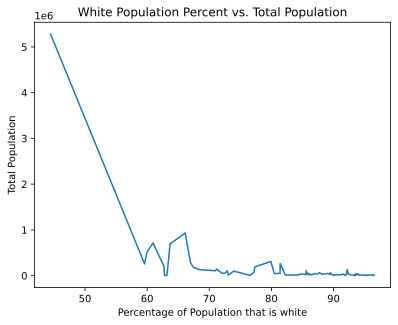

In [ ]:
# this plots percentage of population that is white on the x-axis and
#total population on the y-axis

white_pct = race_df["white_pct"]
total_pop = race_df["total"]

fig, ax = plt.subplots()
ax.plot(white_pct, total_pop)
ax.set_xlabel("Percentage of Population that is white")
ax.set_ylabel("Total Population")
ax.set_title("White Population Percent vs. Total Population")
fig.savefig("line.png") #this is how you save a plot
fig.savefig("line.svg")
plt.show()

# plt.plot(x=white_pct, y=total_pop)
# plt.savefig("line.png") #this is how you save a plot
# plt.savefig("line.svg")
# plt.xlabel("Percentage of Population that is white")
# plt.ylabel("Total Population")
# plt.title("White Population Percent vs. Total Population")
# plt.show()



### Scatter Plots

We can also plot the data as individual points instead of lines.

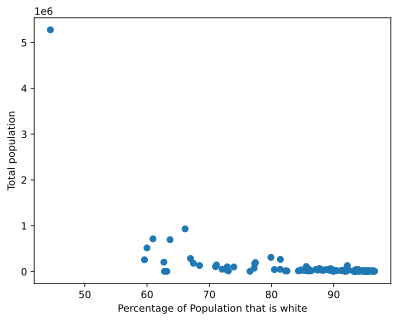

In [ ]:

fig, ax = plt.subplots()
ax.scatter(white_pct, total_pop)  # scatter instead of plot here
ax.set_xlabel("Percentage of Population that is white")
ax.set_ylabel("Total population")
plt.show()

### Mixing and Matching


We can also combine different plot types into one shared plot.



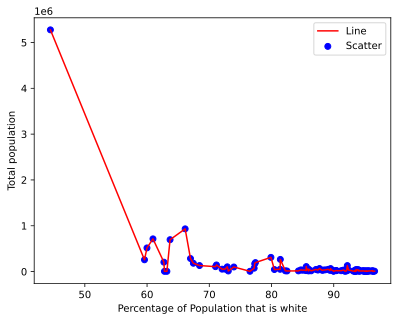

In [ ]:
fig, ax = plt.subplots()
ax.plot(white_pct, total_pop, label="Line", color="red")
ax.scatter(white_pct, total_pop, label="Scatter", color="blue")

ax.set_xlabel("Percentage of Population that is white")
ax.set_ylabel("Total population")
ax.legend(loc="upper right") # where to put the legend in the plot

plt.show()

**Try it!**


Take a look at the [Matplotlib documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) and figure out how to make the points in the scatter plot above smaller.


### Histograms

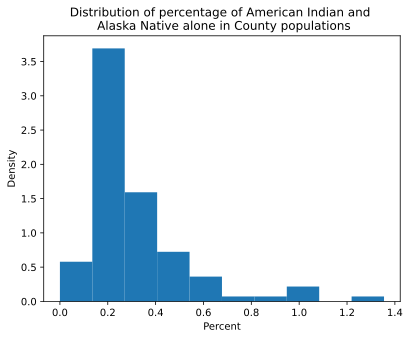

In [ ]:
fig, ax = plt.subplots()
ax.hist(race_df["amin_pct"] , bins=10, density=True)
ax.set_title("Distribution of percentage of American Indian and \n Alaska Native alone in County populations")
ax.set_xlabel("Percent")
ax.set_ylabel("Density")
plt.show()

We can also create a histogram using Panda's `.hist` function, which wraps around matplotlib's histogram function.

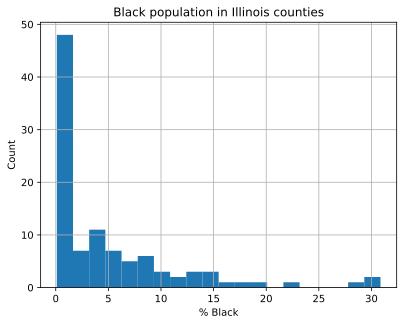

In [ ]:
ax = race_df["black_pct"].hist(bins=20)
ax.set_xlabel("% Black")
ax.set_ylabel("Count")
ax.set_title("Black population in Illinois counties")
plt.show()

This histogram indicates that most counties in Illinois have a relatively small Black population share (most of the mass is below the 10% mark), but there are a few outlying counties with a large concentration of Black population.

### Visualizing demographics with a pie chart

We can visualize the demographic breakdown of a particular county with [Pandas' pie chart function](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.pie.html), which wraps around matplotlib's pie chart function.

In [ ]:
pie_df.T

NameError: name 'pie_df' is not defined

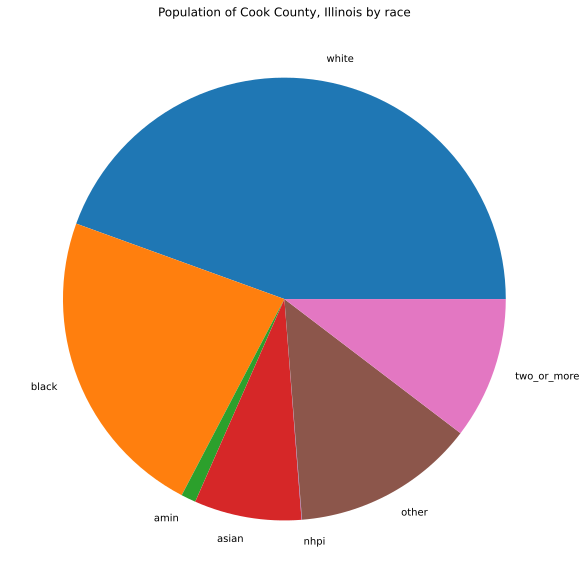

In [ ]:
pie_df = race_df[p1_population_columns.values()] #selects only population counts for all races
county = "Cook County, Illinois"
ax = pie_df.T.plot.pie(y=county, figsize=(10, 10), legend=False)  # what does T do?
ax.set_title(f"Population of {county} by race")
ax.set_ylabel("")
plt.show()

We can visualize the demographic breakdown of the whole state in a similar fashion: first, we compute total population by race for the entire state (as illustrated in the section above), and then we plot the resulting Pandas `Series`. This pie chart improves on the county-level pie chart above by showing percentages for each racial category (rounded to the nearest 0.1%).

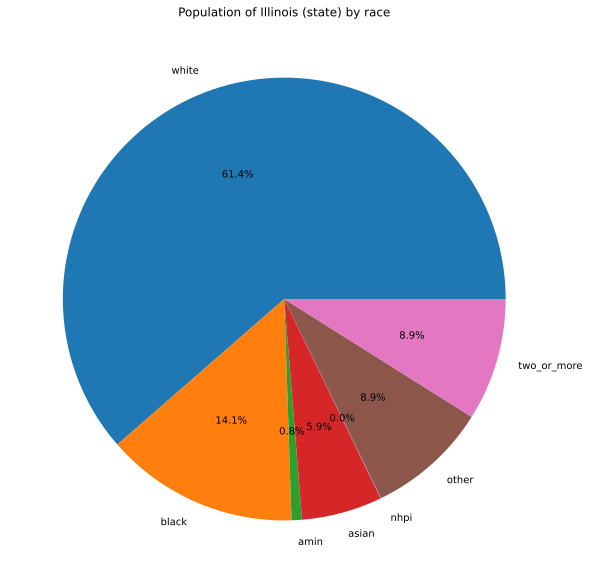

In [ ]:
ax = pie_df.sum(axis=0).plot.pie(figsize=(10, 10), autopct="%1.1f%%")
ax.set_ylabel("")
ax.set_title(f"Population of {state} (state) by race")
plt.show()

## Adding a dimension: Hispanic or Latino origin

The U.S. Census Bureau does not consider "Hispanic or Latino" a racial category; [rather, it is an ethnic category](https://www.census.gov/acs/www/about/why-we-ask-each-question/ethnicity/) ([this may change with the 2030 Census](https://www.npr.org/2023/01/26/1151608403/mena-race-categories-us-census-middle-eastern-latino-hispanic)). Hispanic or Latino origin and racial identification were therefore considered in separate questions on the 2020 Census questionnaire (if you're curious about the precise wording of the questions, see [this PDF of the questionnaire](https://www2.census.gov/programs-surveys/decennial/2020/technical-documentation/questionnaires-and-instructions/questionnaires/2020-informational-questionnaire-english_DI-Q1.pdf)).

[Table P2](https://data.census.gov/table/DECENNIALPL2020.P2?g=040XX00US36) contains population totals broken down by both race _and_ Hispanic/Latino origin. Let's retrieve county-level statistics from this table. (As with Table P1, column definitions are available in the [API documentation](https://api.census.gov/data/2020/dec/pl/variables.html).) When we rename columns derived from Table P2, **we'll use the prefix `nh_` for columns containing non-Hispanic population and the prefix `h_` for columns containing Hispanic population.**

In [ ]:
p2_non_hispanic_population_columns = {
    "P2_005N": "nh_white",  # White alone
    "P2_006N": "nh_black",  # Black or African American alone
    "P2_007N": "nh_amin",  # American Indian and Alaska Native alone
    "P2_008N": "nh_asian",  # Asian alone
    "P2_009N": "nh_nhpi",  # Native Hawaiian and Other Pacific Islander alone
    "P2_010N": "nh_other",  # Some Other Race alone
    "P2_011N": "nh_two_or_more",  # Two or more races
}

In [ ]:
county_non_hispanic_populations = census.pl.get(
    ("NAME", *p2_non_hispanic_population_columns),
    geo={
        "for": "county:*",
        "in": f"state:{state.fips}",
    },
)

In [ ]:
race_ethnicity_df = pd.DataFrame(county_non_hispanic_populations)

In [ ]:
race_ethnicity_df.head(5)

,NAME,P2_005N,P2_006N,P2_007N,P2_008N,P2_009N,P2_010N,P2_011N,state,county
0,"Adams County, Illinois",58389.0,2464.0,92.0,500.0,33.0,223.0,2749.0,17,001
1,"Alexander County, Illinois",3274.0,1612.0,22.0,6.0,0.0,8.0,236.0,17,003
2,"Bond County, Illinois",14264.0,1073.0,52.0,94.0,11.0,93.0,534.0,17,005
3,"Boone County, Illinois",36689.0,1171.0,72.0,637.0,9.0,181.0,1809.0,17,007
4,"Brown County, Illinois",4764.0,1035.0,7.0,11.0,0.0,2.0,143.0,17,009


We can apply the same postprocessing steps we applied to Table P1 to clean up the column names.

In [ ]:
race_ethnicity_df = (
    race_ethnicity_df.rename(
        columns={"NAME": "name", **p2_non_hispanic_population_columns}
    )
    .drop(columns=["state", "county"])
    .set_index("name")
)

In [ ]:
race_ethnicity_df

,nh_white,nh_black,nh_amin,nh_asian,nh_nhpi,nh_other,nh_two_or_more
name,,,,,,,
"Adams County, Illinois",58389.0,2464.0,92.0,500.0,33.0,223.0,2749.0
"Alexander County, Illinois",3274.0,1612.0,22.0,6.0,0.0,8.0,236.0
"Bond County, Illinois",14264.0,1073.0,52.0,94.0,11.0,93.0,534.0
"Boone County, Illinois",36689.0,1171.0,72.0,637.0,9.0,181.0,1809.0
"Brown County, Illinois",4764.0,1035.0,7.0,11.0,0.0,2.0,143.0
...,...,...,...,...,...,...,...
"Whiteside County, Illinois",45341.0,741.0,60.0,306.0,9.0,149.0,1954.0
"Will County, Illinois",418418.0,79256.0,711.0,42416.0,82.0,2105.0,22516.0
"Williamson County, Illinois",58193.0,2809.0,230.0,771.0,9.0,207.0,3155.0


Table P2 only includes _non_-Hispanic population by race, but we can easily derive Hispanic population by race by incorporating totals from Table P1.

In [ ]:
for category in categories:
    race_ethnicity_df[f"h_{category}"] = (
        race_df[category] - race_ethnicity_df[f"nh_{category}"]
    )

In [ ]:
race_ethnicity_df.head(5)

,nh_white,nh_black,nh_amin,nh_asian,nh_nhpi,nh_other,nh_two_or_more,h_white,h_black,h_amin,h_asian,h_nhpi,h_other,h_two_or_more
name,,,,,,,,,,,,,,
"Adams County, Illinois",58389.0,2464.0,92.0,500.0,33.0,223.0,2749.0,448.0,37.0,12.0,13.0,6.0,303.0,468.0
"Alexander County, Illinois",3274.0,1612.0,22.0,6.0,0.0,8.0,236.0,37.0,5.0,2.0,0.0,0.0,12.0,26.0
"Bond County, Illinois",14264.0,1073.0,52.0,94.0,11.0,93.0,534.0,182.0,4.0,0.0,11.0,0.0,267.0,140.0
"Boone County, Illinois",36689.0,1171.0,72.0,637.0,9.0,181.0,1809.0,2077.0,74.0,426.0,22.0,15.0,5995.0,4271.0
"Brown County, Illinois",4764.0,1035.0,7.0,11.0,0.0,2.0,143.0,15.0,19.0,4.0,1.0,0.0,208.0,35.0


In [ ]:
race_ethnicity_df["total"] = race_ethnicity_df.sum(axis=1)

In [ ]:
non_hispanic_categories = list(p2_non_hispanic_population_columns.values())
non_hispanic_categories

['nh_white',
 'nh_black',
 'nh_amin',
 'nh_asian',
 'nh_nhpi',
 'nh_other',
 'nh_two_or_more']

For convenience, let's construct subtotals for the Hispanic and non-Hispanic populations.

In [ ]:
race_ethnicity_df["nh_total"] = race_ethnicity_df[non_hispanic_categories].sum(axis=1)

In [ ]:
hispanic_categories = [
    "h_white",
    "h_black",
    "h_asian",
    "h_nhpi",
    "h_other",
    "h_two_or_more",
]

In [ ]:
race_ethnicity_df["h_total"] = race_ethnicity_df[hispanic_categories].sum(axis=1)

In [ ]:
race_ethnicity_df.head(5)

,nh_white,nh_black,nh_amin,nh_asian,nh_nhpi,nh_other,nh_two_or_more,h_white,h_black,h_amin,h_asian,h_nhpi,h_other,h_two_or_more,total,nh_total,h_total
name,,,,,,,,,,,,,,,,,
"Adams County, Illinois",58389.0,2464.0,92.0,500.0,33.0,223.0,2749.0,448.0,37.0,12.0,13.0,6.0,303.0,468.0,65737.0,64450.0,1275.0
"Alexander County, Illinois",3274.0,1612.0,22.0,6.0,0.0,8.0,236.0,37.0,5.0,2.0,0.0,0.0,12.0,26.0,5240.0,5158.0,80.0
"Bond County, Illinois",14264.0,1073.0,52.0,94.0,11.0,93.0,534.0,182.0,4.0,0.0,11.0,0.0,267.0,140.0,16725.0,16121.0,604.0
"Boone County, Illinois",36689.0,1171.0,72.0,637.0,9.0,181.0,1809.0,2077.0,74.0,426.0,22.0,15.0,5995.0,4271.0,53448.0,40568.0,12454.0
"Brown County, Illinois",4764.0,1035.0,7.0,11.0,0.0,2.0,143.0,15.0,19.0,4.0,1.0,0.0,208.0,35.0,6244.0,5962.0,278.0


Now that we've broken down the state population along two dimensions (race and Hispanic/Latino origin), we can answer some more sophisticated demographic questions: for instance, how does the distribution of racial identification differ between the Hispanic and non-Hispanic populations?

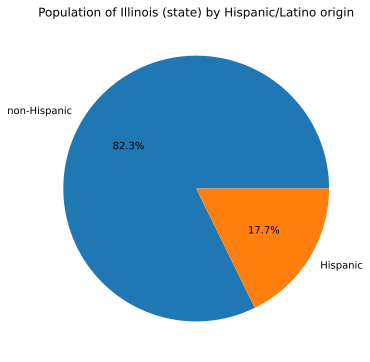

In [ ]:
ax = (
    race_ethnicity_df[["nh_total", "h_total"]]
    .rename(columns={"nh_total": "non-Hispanic", "h_total": "Hispanic"})
    .sum(axis=0)
    .plot.pie(figsize=(6, 6), autopct="%1.1f%%")
)
ax.set_ylabel("")
ax.set_title(f"Population of {state} (state) by Hispanic/Latino origin")
plt.show()

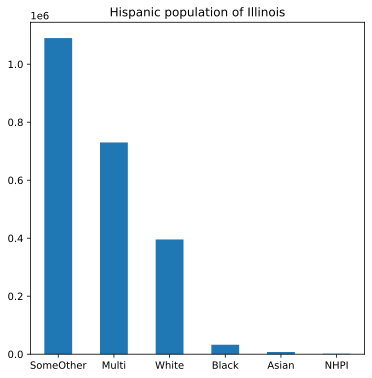

In [ ]:
ax = (
    race_ethnicity_df[hispanic_categories]
    .rename(
        columns={
            "h_other": "SomeOther",
            "h_asian": "Asian",
            "h_black": "Black",
            "h_white": "White",
            "h_two_or_more": "Multi",
            "h_amin": "AMIN",
            "h_nhpi": "NHPI",
        }
    )
    .sum(axis=0)
    .sort_values(ascending=False)
    .plot.bar(figsize=(6, 6), rot=0)
)
ax.set_title(f"Hispanic population of {state}")
plt.show()

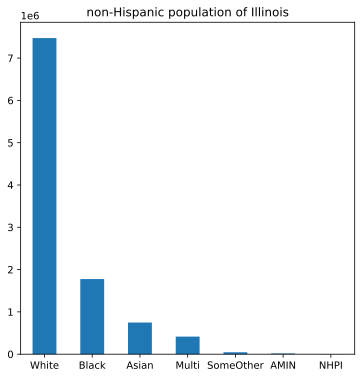

In [ ]:
ax = (
    race_ethnicity_df[non_hispanic_categories]
    .rename(
        columns={
            "nh_other": "SomeOther",
            "nh_asian": "Asian",
            "nh_black": "Black",
            "nh_white": "White",
            "nh_two_or_more": "Multi",
            "nh_amin": "AMIN",
            "nh_nhpi": "NHPI",
        }
    )
    .sum(axis=0)
    .sort_values(ascending=False)
    .plot.bar(figsize=(6, 6), rot=0)
)
ax.set_title(f"non-Hispanic population of {state}")
plt.show()
#plt.savefig("lab_turn_in.svg")

## LAB TURN IN PLOT

Go to the code block where we designated Illinois as the state and change it to a different state. Then, restart the session and run all to re-produce the  plot directly above (non-hispanic population) for that state, make sure to uncomment the save figure line so you can export the plot and turn it in on gradescope.

## Homework 2, due Tuesday Feb 11, 1:25pm



**Warm up question:**  Among all counties in Illinois with no more than 10,000 people total, which county has the second largest percentage of Black population? Explain in simple English how you used the tools we learned to find this information.


For the **data product** part of your homework, explore the census race/ethnicity data.  Pose ONE question and show us a plot that answers it.  Here are some examples to get you thinking...
- How does the share of "white" people change in Texas if I only sort by race (ignoring ethnicity), or if I consider both race and ethnicity and treat Hispanic as a race?  (This could be a pair of pie charts side-by-side, for instance.)
- Which state had its number of multi-racial respondents jump most in absolute numbers between the 2010 and 2020 Census?
- What's the share of Hispanic respondents choosing "Some Other Race" in California? Is it very different from Florida?
- What's the Whitest state with at least 3 million people?
- Which state has the highest share of people who said they belong to ALL SIX races?  (note: to do this, you'd need to fetch new columns from the API)

Be creative!


**THIS NEEDS MOON TO UPDATE**
For the **reading response** part of your homework, refer to the chapter by Nobles.  Pick out and quote one juicy sentence that you underlined when you read the chapter.  React to it and connect it to something from either Scott or Hacking (two other authors we've been discussing).

In [ ]:

#HW CODE ANSWER --- DELETE BEFORE POST
race_df.loc[race_df["total"]<10000].sort_values(by="black_pct", ascending =False)

,white,black,amin,asian,nhpi,other,two_or_more,total,white_pct,black_pct,amin_pct,asian_pct,nhpi_pct,other_pct,two_or_more_pct
name,,,,,,,,,,,,,,,
"Alexander County, Illinois",3311.0,1617.0,24.0,6.0,0.0,20.0,262.0,5240.0,63.187023,30.858779,0.458015,0.114504,0.000000,0.381679,5.000000
"Pulaski County, Illinois",3261.0,1466.0,41.0,13.0,0.0,162.0,250.0,5193.0,62.796072,28.230310,0.789524,0.250337,0.000000,3.119584,4.814173
"Brown County, Illinois",4779.0,1054.0,11.0,12.0,0.0,210.0,178.0,6244.0,76.537476,16.880205,0.176169,0.192184,0.000000,3.363229,2.850737
"Schuyler County, Illinois",6211.0,289.0,29.0,26.0,2.0,45.0,300.0,6902.0,89.988409,4.187192,0.420168,0.376702,0.028977,0.651985,4.346566
"Pope County, Illinois",3513.0,43.0,7.0,19.0,0.0,17.0,164.0,3763.0,93.356365,1.142705,0.186022,0.504916,0.000000,0.451767,4.358225
"Gallatin County, Illinois",4700.0,26.0,5.0,24.0,0.0,22.0,169.0,4946.0,95.026284,0.525677,0.101092,0.485241,0.000000,0.444804,3.416903
"Hamilton County, Illinois",7601.0,41.0,16.0,13.0,0.0,25.0,297.0,7993.0,95.095709,0.512949,0.200175,0.162642,0.000000,0.312774,3.715751
"Henderson County, Illinois",6092.0,30.0,12.0,17.0,5.0,27.0,204.0,6387.0,95.381243,0.469704,0.187882,0.266166,0.078284,0.422734,3.193988
"Putnam County, Illinois",5175.0,26.0,13.0,18.0,4.0,132.0,269.0,5637.0,91.804151,0.461238,0.230619,0.319319,0.070960,2.341671,4.772042
